# Amostragem Complexa Aplicada à Saúde 📊🏥



## 📍 Um guia teórico e prático com Python + R no Google Colab

Este notebook foi reorganizado como uma **aula contínua**, e não como uma coleção de conceitos independentes.

A sequência de aprendizagem será sempre a mesma:

1. **problema real**: qual dificuldade aparece na pesquisa;
2. **conceito**: qual ideia estatística responde a essa dificuldade;
3. **teoria**: como a ideia é formalizada;
4. **exemplo em saúde**: como isso aparece em um inquérito;
5. **código**: como representar o problema e a solução;
6. **interpretação**: o que o resultado significa e o que daria errado se o desenho fosse ignorado.

A maior parte das simulações será feita em Python. Quando chegarmos à análise formal de desenhos amostrais complexos, utilizaremos o pacote `survey` do R em células específicas dentro do próprio Colab.

### 🎯 Objetivos de aprendizagem

Ao final, você deverá conseguir:

- distinguir população-alvo, população acessível, cadastro amostral e amostra;
- distinguir parâmetro, estimador e estimativa;
- compreender de onde surge a incerteza amostral;
- usar a amostragem aleatória simples como referência;
- explicar estratificação, conglomerados, PSU e múltiplos estágios;
- calcular probabilidades de inclusão;
- compreender por que o peso básico é o inverso da probabilidade de inclusão;
- interpretar sobreamostragem e seleção com probabilidades desiguais;
- diferenciar peso básico de peso final;
- compreender ajuste por não resposta, pós-estratificação, rake e calibração;
- explicar como conglomerados, estratos e pesos alteram a variância;
- interpretar ICC, DEFF, FPC e tamanho amostral efetivo;
- construir e auditar um objeto `svydesign()`;
- estimar prevalências, médias, totais e intervalos de confiança;
- realizar análises de domínio, testes e regressões respeitando o desenho.

### 🗺️ Mapa do notebook

1. Por que amostrar e por que o desenho importa  
2. Fundamentos da inferência amostral  
3. Amostragem Aleatória Simples como referência  
4. Estratificação  
5. Conglomerados e PSU  
6. Múltiplos estágios  
7. Probabilidades desiguais, sobreamostragem e PPS  
8. Pesos amostrais  
9. Não resposta  
10. Pós-estratificação, rake e calibração  
11. Variância, ICC, DEFF, FPC e tamanho efetivo  
12. Construção de uma pesquisa complexa completa em Python  
13. Preparação do R no Colab  
14. Construção do desenho com `survey`  
15. Estimativas, intervalos e domínios  
16. Testes e regressão  
17. Diagnóstico e problemas frequentes  
18. Como ler uma base real de survey  
19. Estudo de caso final  
20. Exercícios e referências

## 🔍 Por que amostrar e por que o desenho importa



Imagine que queremos estimar a prevalência de hipertensão entre **1 milhão de adultos** de uma cidade.

O cenário ideal seria medir a pressão arterial de todos. Isso seria um censo. Na maior parte das situações, porém, é caro, lento e desnecessário. Em vez disso, observamos uma parte da população e usamos essa informação para aprender sobre o todo.

Esse é o papel da **amostra**.

A questão estatística fundamental é:

> Como uma informação produzida em algumas pessoas pode ser usada para falar sobre uma população muito maior?

A resposta depende de **como as pessoas foram selecionadas**.

Compare duas pesquisas com 2.000 participantes:

**Pesquisa A:** 2.000 adultos são sorteados de uma lista contendo todos os residentes.

**Pesquisa B:** são entrevistados os primeiros 2.000 pacientes que chegam a um hospital universitário.

As duas bases possuem 2.000 linhas, mas não possuem a mesma capacidade de representar a cidade. Na primeira existe um mecanismo probabilístico conhecido. Na segunda, entrar na amostra depende de procurar aquele hospital, algo potencialmente relacionado a idade, gravidade, local de residência e condição socioeconômica.

Portanto:

> O tamanho da amostra não é suficiente. Precisamos conhecer o mecanismo que produziu a amostra.

A amostragem complexa aparece porque, no mundo real, frequentemente não é possível ou desejável sortear indivíduos diretamente de toda a população. Pesquisas podem selecionar regiões, setores censitários, escolas, UBS, domicílios e pessoas em etapas sucessivas. Podem também selecionar certos grupos com maior probabilidade e depois corrigir diferenças de resposta.

Essa complexidade operacional precisa aparecer na análise estatística.

## 🧠 Fundamentos


### População-alvo, população acessível e cadastro amostral

A **população-alvo** é o conjunto sobre o qual queremos fazer uma afirmação. Exemplo: todos os adultos residentes em Belo Horizonte em determinado ano.

A **população acessível** é a parcela que o mecanismo de coleta consegue efetivamente alcançar.

O **cadastro amostral**, ou *sampling frame*, é a estrutura concreta utilizada para realizar o sorteio. Pode ser uma lista de domicílios, escolas, setores censitários, unidades de saúde, telefones ou registros administrativos.

Se o cadastro não cobre adequadamente a população-alvo, surge **erro de cobertura**.

### Unidade amostral e unidade de análise



A unidade sorteada nem sempre é a unidade analisada.

Em uma pesquisa escolar podemos sortear escolas, depois turmas, e finalmente observar estudantes. A escola pode ser a unidade primária de amostragem, a turma uma unidade de segundo estágio e o estudante a unidade final de análise.

### Parâmetro, estimador e estimativa

Suponha que a prevalência verdadeira de obesidade na população seja:

\[
P=0,25
\]

Esse valor é um **parâmetro populacional**. Como normalmente não observamos toda a população, selecionamos uma amostra. Se nela encontramos: P^=0,27, o valor 0,27 é uma **estimativa**. O **estimador** é a regra de cálculo usada para transformar os dados da amostra em uma tentativa de estimar o parâmetro. Para uma proporção simples:




\[
\hat P =
\frac{\text{número de pessoas com o desfecho}}
{\text{número de pessoas observadas}}
\]

Assim:

| Conceito | Significado |
|---|---|
| Parâmetro | valor verdadeiro da população |
| Estimador | regra usada para estimá-lo |
| Estimativa | valor numérico obtido em uma amostra |


### Por que existe erro padrão?




Se repetíssemos o sorteio muitas vezes, obteríamos amostras diferentes e, portanto, estimativas ligeiramente diferentes.

O **erro padrão** mede quanto uma estimativa tenderia a variar entre possíveis amostras produzidas pelo mesmo desenho.

Por isso existem duas perguntas distintas:

1. qual foi a estimativa;
2. quão incerta é essa estimativa.

Essa separação será essencial. Pesos podem modificar fortemente a estimativa pontual, enquanto conglomerados e estratos têm papel central na variância.


### Inferência baseada no desenho

Na perspectiva clássica da amostragem probabilística, podemos imaginar que os valores existentes na população são fixos e o **sorteio da amostra** é aleatório.

A incerteza surge porque outra execução do mesmo desenho poderia selecionar outras unidades.

Essa é a lógica da **inferência baseada no desenho**.

Consequentemente, a maneira como uma pessoa chegou à base é parte da informação estatística. Por isso variáveis como estrato, PSU, probabilidade de inclusão e peso não são meros metadados administrativos. Elas descrevem o mecanismo que permite ir da amostra para a população.

## 🧮  Amostragem Aleatória Simples como referência

A AAS será nossa referência.

Em uma AAS sem reposição de tamanho `n` retirada de uma população de tamanho `N`:

- cada unidade possui a mesma probabilidade de inclusão;
- não há estratos;
- não há conglomerados;
- as unidades são selecionadas diretamente da população.

### Probabilidade de inclusão na AAS

Se selecionamos n pessoas de uma população com N indivíduos por amostragem aleatória simples, cada pessoa tem a mesma probabilidade de ser incluída na amostra:


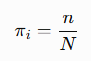

Essa quantidade é chamada de probabilidade de inclusão.

A partir dela, definimos o peso amostral básico de cada indivíduo como o inverso da probabilidade de inclusão:

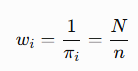

Isso significa que, na AAS, todas as pessoas da amostra recebem o mesmo peso.

Como todos os pesos são iguais, a análise ponderada coincide com a análise usual. Em outras palavras, na amostragem aleatória simples, calcular uma média ponderada produz o mesmo resultado que calcular a média simples.

### Criando uma população fictícia de saúde


Durante toda a aula utilizaremos a mesma população simulada.

Isso é didaticamente útil porque conhecemos a **verdade populacional**. Podemos então retirar diferentes amostras e verificar como o desenho modifica a estimativa.

A população terá regiões, territórios, idade, sexo, escolaridade, obesidade, hipertensão e diabetes. Os territórios terão um pequeno efeito próprio, criando semelhança entre moradores de uma mesma área.

In [31]:
# ============================================================
# POPULAÇÃO FICTÍCIA USADA EM TODA A AULA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

N = 120_000
regioes = np.array(["Norte", "Sul", "Leste", "Oeste"])
psus_por_regiao = 20

# Tabela com os territórios da população.
psu_tabela = pd.DataFrame(
    [
        (regiao, f"{regiao[:1]}_{i:02d}")
        for regiao in regioes
        for i in range(psus_por_regiao)
    ],
    columns=["regiao", "psu"]
)

# PSUs têm tamanhos diferentes.
psu_tabela["tamanho_relativo"] = rng.lognormal(
    mean=0,
    sigma=0.35,
    size=len(psu_tabela)
)

# Efeito territorial compartilhado por pessoas da mesma PSU.
psu_tabela["efeito_psu"] = rng.normal(
    0,
    0.35,
    size=len(psu_tabela)
)

# Distribuição da população entre as regiões.
prob_regiao = np.array([0.22, 0.28, 0.25, 0.25])
regiao_pop = rng.choice(regioes, size=N, p=prob_regiao)

psu_pop = np.empty(N, dtype=object)
efeito_psu_pop = np.empty(N)

# Distribuímos os indivíduos entre as PSUs de sua região.
for regiao in regioes:
    mascara = regiao_pop == regiao
    sub = psu_tabela.loc[psu_tabela["regiao"] == regiao].reset_index(drop=True)

    prob = sub["tamanho_relativo"].to_numpy()
    prob = prob / prob.sum()

    indices = rng.choice(
        len(sub),
        size=mascara.sum(),
        replace=True,
        p=prob
    )

    psu_pop[mascara] = sub["psu"].to_numpy()[indices]
    efeito_psu_pop[mascara] = sub["efeito_psu"].to_numpy()[indices]

# Características individuais.
idade = np.clip(rng.normal(46, 17, N), 18, 90)
sexo = rng.choice(["Feminino", "Masculino"], size=N, p=[0.53, 0.47])

escolaridade = rng.choice(
    ["0-8 anos", "9-11 anos", "12+ anos"],
    size=N,
    p=[0.32, 0.38, 0.30]
)

# Obesidade depende de características individuais e do território.
logit_obes = (
    -2.1
    + 0.025 * (idade - 40)
    + 0.18 * (sexo == "Feminino")
    + 0.35 * (escolaridade == "0-8 anos")
    + efeito_psu_pop
)

p_obes = 1 / (1 + np.exp(-logit_obes))
obesidade = rng.binomial(1, p_obes)

# Hipertensão depende de idade, obesidade, escolaridade e território.
logit_has = (
    -3.2
    + 0.055 * (idade - 40)
    + 0.45 * obesidade
    + 0.20 * (escolaridade == "0-8 anos")
    + 0.60 * efeito_psu_pop
)

p_has = 1 / (1 + np.exp(-logit_has))
hipertensao = rng.binomial(1, p_has)

# Diabetes depende principalmente de idade e obesidade.
logit_dm = (
    -4.0
    + 0.045 * (idade - 40)
    + 0.55 * obesidade
)

p_dm = 1 / (1 + np.exp(-logit_dm))
diabetes = rng.binomial(1, p_dm)

pop = pd.DataFrame({
    "id": np.arange(1, N + 1),
    "regiao": regiao_pop,
    "psu": psu_pop,
    "idade": idade.round(1),
    "sexo": sexo,
    "escolaridade": escolaridade,
    "obesidade": obesidade,
    "hipertensao": hipertensao,
    "diabetes": diabetes,
})

pop.head()

,id,regiao,psu,idade,sexo,escolaridade,obesidade,hipertensao,diabetes
0,1,Norte,N_12,51.9,Feminino,9-11 anos,0,0,0
1,2,Leste,L_11,67.7,Feminino,0-8 anos,1,0,0
2,3,Sul,S_05,18.0,Masculino,9-11 anos,0,0,0
3,4,Oeste,O_11,25.4,Masculino,0-8 anos,0,0,0
4,5,Oeste,O_08,52.8,Masculino,9-11 anos,0,1,0


In [32]:
# ============================================================
# PARÂMETROS VERDADEIROS
# ============================================================
# Em uma pesquisa real esses valores seriam desconhecidos.
# Aqui eles servem para avaliar as estimativas das amostras.

parametros_pop = pd.Series({
    "N": len(pop),
    "idade_media": pop["idade"].mean(),
    "obesidade": pop["obesidade"].mean(),
    "hipertensao": pop["hipertensao"].mean(),
    "diabetes": pop["diabetes"].mean(),
})

parametros_pop

,0
N,120000.000000
idade_media,46.316737
obesidade,0.159158
hipertensao,0.087292
diabetes,0.033917


### Erro padrão de uma proporção em uma AAS

Quando estimamos uma proporção a partir de uma amostra, a estimativa varia de uma amostra para outra. O erro padrão quantifica essa variabilidade.

Ignorando, por enquanto, a correção para população finita, o erro padrão de uma proporção em uma amostragem aleatória simples é:

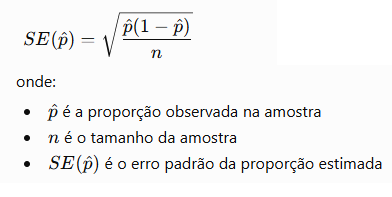

Por exemplo, se encontramos uma prevalência de obesidade de 25% em uma amostra de 1.000 pessoas:

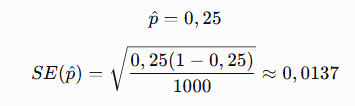

Ou seja, o erro padrão é de aproximadamente 1,37 ponto percentual.

Essa fórmula parte de uma suposição importante: as observações são tratadas como independentes e provenientes de uma amostragem aleatória simples.

In [33]:
# ============================================================
# RETIRANDO UMA AAS
# ============================================================

n_aas = 2_000

aas = pop.sample(
    n=n_aas,
    random_state=SEED
).copy()

p_hat = aas["obesidade"].mean()

se = np.sqrt(
    p_hat * (1 - p_hat) / len(aas)
)

ic = (
    p_hat - 1.96 * se,
    p_hat + 1.96 * se
)

print(f"Verdade populacional: {pop['obesidade'].mean():.3%}")
print(f"Estimativa AAS:       {p_hat:.3%}")
print(f"Erro padrão:          {se:.4f}")
print(f"IC95% aproximado:     {ic[0]:.3%} a {ic[1]:.3%}")

Verdade populacional: 15.916%
Estimativa AAS:       15.800%
Erro padrão:          0.0082
IC95% aproximado:     14.201% a 17.399%


### Leitura do resultado



A estimativa da AAS não precisa ser exatamente igual ao parâmetro verdadeiro. Existe variabilidade amostral.

O ponto importante é que conhecemos o mecanismo de seleção e conseguimos quantificar a incerteza associada a ele.

Agora começaremos a alterar esse mecanismo.

## 🧠 Complexificação da Amostragem

Em uma amostra complexa  (que introduz estratificação, conglomerados, pesos, etc), duas perguntas precisam ser separadas:

### 1. Quem cada indivíduo representa?

Essa pergunta está ligada principalmente aos **pesos amostrais**.

### 2. Quanta informação independente existe na amostra?

Essa pergunta está ligada principalmente a:

- conglomerados;
- estratos;
- número de PSUs;
- pesos desiguais;
- método de estimação da variância.

Uma análise pode produzir uma prevalência aparentemente razoável e ainda assim apresentar **intervalos de confiança e p-valores incorretos**.

Em termos didáticos:

- **pesos** costumam ter grande impacto sobre a estimativa pontual;
- **conglomerados, estratos e pesos desiguais** influenciam a variância;
- a variância determina erro padrão, intervalo de confiança, teste estatístico e p-valor.

Por isso, a pergunta não é apenas:

> "Qual é a prevalência?"

Também é:

> "Quão incerta é essa prevalência, considerando como a amostra foi realmente obtida?"

## 🗂️ Amostragem Estratificada


Na amostragem estratificada, dividimos previamente a população em grupos chamados **estratos** e realizamos seleção dentro de cada estrato.

Exemplos em saúde:

- Unidade da Federação;
- região geográfica;
- urbano versus rural;
- faixa etária;
- tipo de estabelecimento;
- porte do município.

O objetivo pode ser garantir representação ou aumentar precisão.

### Exemplo



Suponha que a cidade possua quatro regiões com perfis diferentes.

Em vez de sortear 2.000 pessoas de toda a cidade de uma única vez, podemos dividir a população previamente e sortear pessoas **separadamente dentro de cada região**.

Esses grupos são os **estratos**.

A estratificação pode:

- garantir presença de grupos importantes;
- permitir controlar a alocação da amostra;
- facilitar estimativas por estrato;
- aumentar a precisão quando os estratos são internamente relativamente homogêneos e diferentes entre si.



### Estrato não é simplesmente uma variável de agrupamento


Um estrato é parte do **desenho amostral**.

Dizer que a base possui uma variável `regiao` não significa automaticamente que a pesquisa foi estratificada por região.

Para ser estrato amostral, a região precisa ter participado da forma como a amostra foi selecionada.

### Como estimamos a média da população?

Primeiro calculamos a média separadamente em cada estrato:

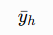

Depois combinamos essas médias considerando quanto cada estrato representa da população:

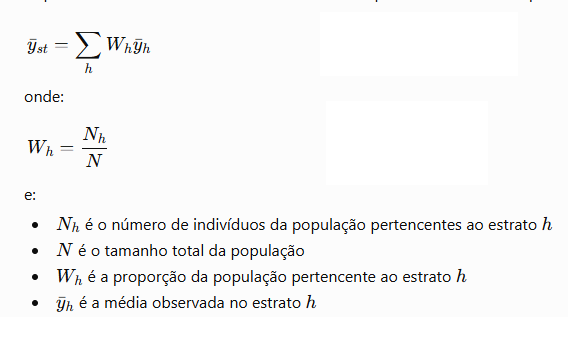

Portanto, cada estrato contribui para a estimativa final proporcionalmente ao tamanho que representa na população.

### Exemplo Teórico

Suponha que uma população seja composta por:

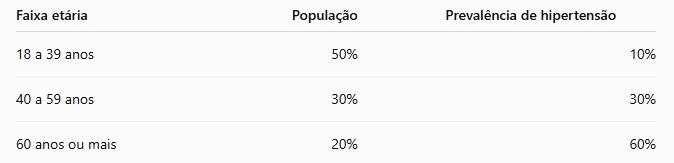

A prevalência populacional estimada seria:

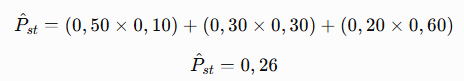

Portanto, a prevalência estimada de hipertensão seria de 26%.

E onde entra a redução da variância?

Na amostragem estratificada, a variância da média pode ser expressa como:

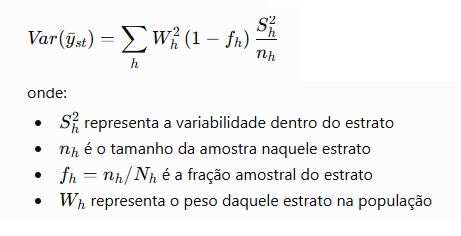

A consequência importante é que, quando os indivíduos dentro de cada estrato são relativamente semelhantes, os valores de Sh2 tendem a ser menores. Isso pode fazer com que a variância da estimativa estratificada seja menor do que aquela obtida por uma amostragem aleatória simples de mesmo tamanho.

> Intuição: na estratificação, organizamos previamente a população em grupos relevantes e fazemos a amostragem dentro deles. Se essa divisão explica parte importante da heterogeneidade da população, sobra menos variabilidade dentro de cada grupo e podemos obter estimativas mais precisas.


Em saúde, por isso, variáveis fortemente relacionadas ao desfecho, como idade, sexo, região geográfica ou características socioeconômicas, podem ser úteis na definição dos estratos.

### Exemplo Prático

Queremos garantir amostra suficiente nas quatro regiões da cidade.

Em vez de sortear 2.000 pessoas da cidade inteira, sorteamos 500 de cada região.

Isso é uma alocação igual entre estratos.

Se as regiões tiverem tamanhos populacionais diferentes, as probabilidades de seleção serão diferentes e os pesos também.

In [34]:
n_por_regiao = 500

estratificada = (
    pop.groupby("regiao", group_keys=False)
       .sample(n=n_por_regiao, random_state=SEED)
       .copy()
)

estratificada["regiao"].value_counts()

,count
regiao,
Leste,500
Norte,500
Oeste,500
Sul,500


In [35]:
distrib_pop = pop["regiao"].value_counts(normalize=True).sort_index()
distrib_amostra = estratificada["regiao"].value_counts(normalize=True).sort_index()

pd.DataFrame({
    "População": distrib_pop,
    "Amostra estratificada": distrib_amostra
})

,População,Amostra estratificada
regiao,,
Leste,0.251967,0.25
Norte,0.218700,0.25
Oeste,0.250175,0.25
Sul,0.279158,0.25


Observe que a amostra tem 25% em cada região, mas a população não.

Se as regiões possuírem prevalências diferentes, a média não ponderada poderá distorcer a estimativa da cidade.

In [36]:
prev_regiao = pop.groupby("regiao")["obesidade"].mean()

prev_bruta_estrat = estratificada["obesidade"].mean()

# Peso = N_h / n_h
N_h = pop["regiao"].value_counts()
n_h = estratificada["regiao"].value_counts()

estratificada["peso_estrato"] = estratificada["regiao"].map(N_h / n_h)

prev_pond_estrat = np.average(
    estratificada["obesidade"],
    weights=estratificada["peso_estrato"]
)

print("Prevalência verdadeira da população:", round(pop["obesidade"].mean(), 4))
print("Prevalência bruta da amostra:", round(prev_bruta_estrat, 4))
print("Prevalência ponderada:", round(prev_pond_estrat, 4))
print("\nPrevalência populacional por região:")
display(prev_regiao.to_frame("obesidade"))

Prevalência verdadeira da população: 0.1592
Prevalência bruta da amostra: 0.1745
Prevalência ponderada: 0.1737

Prevalência populacional por região:


,obesidade
regiao,
Leste,0.179554
Norte,0.146815
Oeste,0.154858
Sul,0.154273


### Por que a estratificação pode reduzir a variância?

A fórmula da variância mostra que importa a variabilidade **dentro** de cada estrato.

A intuição é:

> se conseguimos separar previamente a população em grupos internamente mais homogêneos, sobra menos variabilidade dentro de cada grupo.

Exemplo em saúde: hipertensão varia fortemente com idade. Faixas etárias bem definidas podem separar parte importante dessa heterogeneidade.

Estratificação, portanto, não serve apenas para “garantir pessoas de cada grupo”. Ela também pode melhorar a eficiência estatística.

In [37]:
# ============================================================
# AMOSTRA ESTRATIFICADA POR REGIÃO
# ============================================================

# Selecionamos exatamente 500 pessoas em cada região.
# Isso totaliza 2.000 pessoas, como na AAS anterior.
n_por_regiao = 500

estratificada = (
    pop
    .groupby("regiao", group_keys=False)
    .sample(n=n_por_regiao, random_state=SEED)
    .copy()
)

# Participação de cada região na população.
N_h = pop["regiao"].value_counts().sort_index()
W_h = N_h / len(pop)

# Prevalência observada dentro de cada estrato.
p_h = (
    estratificada
    .groupby("regiao")["obesidade"]
    .mean()
    .sort_index()
)

# Combinamos os estratos usando sua participação populacional.
p_est = (W_h * p_h).sum()

print("Amostra por região:")
print(estratificada["regiao"].value_counts().sort_index())

print(f"\nVerdade populacional:         {pop['obesidade'].mean():.3%}")
print(f"Média simples da amostra:     {estratificada['obesidade'].mean():.3%}")
print(f"Estimativa estratificada:     {p_est:.3%}")

Amostra por região:
regiao
Leste    500
Norte    500
Oeste    500
Sul      500
Name: count, dtype: int64

Verdade populacional:         15.916%
Média simples da amostra:     17.450%
Estimativa estratificada:     17.369%


### O que o exemplo demonstra?



A amostra possui exatamente 25% de participantes de cada região, porque forçamos 500 observações em cada uma.

A população, porém, não possui exatamente 25% em cada região.

Isso não torna o desenho incorreto. Apenas significa que, ao estimar o total da cidade, as regiões devem contribuir conforme o tamanho populacional que representam.

## 🏘️ Amostragem por Conglomerados


Agora imagine que não temos uma lista completa de todos os moradores, mas temos uma lista de UBS.

Podemos:

1. sortear algumas UBS;
2. selecionar pacientes dentro das UBS escolhidas.

As UBS funcionam como **conglomerados**.

Essa estratégia é operacionalmente conveniente, mas cria dependência entre observações. Pessoas atendidas na mesma UBS podem compartilhar território, condições socioeconômicas, oferta de serviços e exposições.



### PSU, Primary Sampling Unit

A **PSU**, ou *Primary Sampling Unit*, é a unidade primária de amostragem. Pode ser uma UBS, escola, setor censitário, município ou outra unidade, dependendo do desenho.

Não confunda PSU com qualquer variável de agrupamento do banco. PSU é definida pelo plano amostral.

Considere:

- Desenho A: 1.600 pessoas distribuídas por toda a cidade.
- Desenho B: 20 UBS × 80 pacientes = 1.600 pessoas.

O número de linhas é igual. A quantidade de informação independente pode não ser.

No desenho B, participantes da mesma UBS são parcialmente semelhantes. Por isso, tratar as 1.600 linhas como completamente independentes pode produzir erro padrão pequeno demais.

In [38]:
# ============================================================
# EXEMPLO DE AMOSTRA POR CONGLOMERADOS
# ============================================================

psus_disponiveis = pop["psu"].drop_duplicates()

# Selecionamos somente 20 PSUs.
psus_sel_cluster = psus_disponiveis.sample(
    n=20,
    random_state=SEED
)

# Dentro de cada PSU selecionamos 80 pessoas.
amostra_cluster = (
    pop[pop["psu"].isin(psus_sel_cluster)]
    .groupby("psu", group_keys=False)
    .sample(n=80, random_state=SEED, replace=False)
    .copy()
)

print("Pessoas:", len(amostra_cluster))
print("PSUs:", amostra_cluster["psu"].nunique())

# Prevalência de obesidade em cada PSU.
prev_por_psu = (
    amostra_cluster
    .groupby("psu")["obesidade"]
    .mean()
    .sort_values()
)

prev_por_psu

Pessoas: 1600
PSUs: 20


,obesidade
psu,
O_19,0.0750
O_12,0.1125
N_12,0.1250
O_09,0.1375
O_16,0.1375
N_17,0.1500
O_07,0.1500
N_00,0.1625
O_05,0.1625


A variação das prevalências entre PSUs mostra que os territórios não são equivalentes.

Quando várias pessoas vêm do mesmo território, parte da informação individual carrega o mesmo componente contextual.

Mais adiante formalizaremos isso com ICC e DEFF.

### Por que `n = 1.600` não conta toda a história?


Se as 1.600 pessoas viessem de uma AAS, teríamos 1.600 seleções espalhadas por toda a cidade.

Na amostra por conglomerados, parte da informação é repetitiva porque pessoas do mesmo território se parecem.

Então o **tamanho nominal da amostra** pode superestimar a quantidade de informação independente.




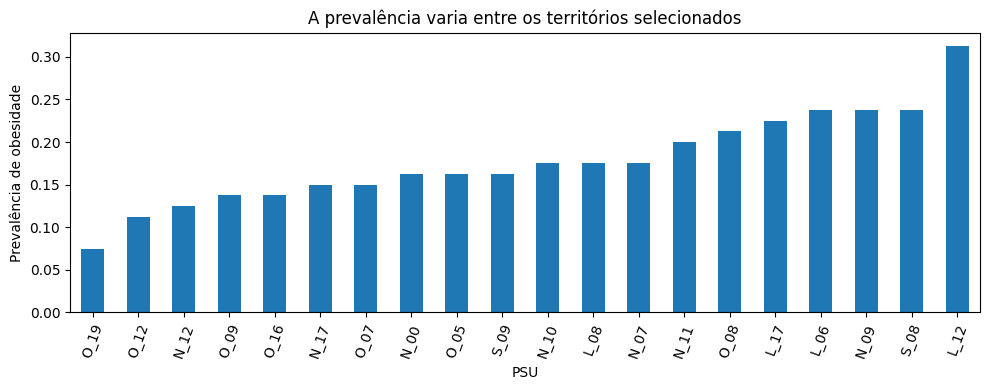

In [39]:
prev_por_psu = amostra_cluster.groupby("psu")["obesidade"].mean().sort_values()

plt.figure(figsize=(10, 4))
prev_por_psu.plot(kind="bar")
plt.ylabel("Prevalência de obesidade")
plt.xlabel("PSU")
plt.title("A prevalência varia entre os territórios selecionados")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

## 🎬 Amostragem em múltiplos estágios

Muitos inquéritos não selecionam apenas um tipo de unidade. A seleção acontece em etapas:

1. municípios;
2. setores censitários;
3. domicílios;
4. pessoas.

Uma pessoa só chega à amostra se atravessar todas as etapas.



Grandes inquéritos frequentemente selecionam unidades em sequência.

Exemplo genérico:

```text
Município
   ↓
Setor censitário
   ↓
Domicílio
   ↓
Pessoa
```

Outro exemplo:

```text
Escola
   ↓
Turma
   ↓
Estudantes
```

A probabilidade final de inclusão depende das probabilidades dos vários estágios.

### Probabilidade final em múltiplos estágios

Em muitos estudos de saúde, não sorteamos diretamente indivíduos de toda a população. O processo ocorre em etapas sucessivas.

Imagine uma pesquisa em que:

* primeiro sorteamos algumas UBS de uma cidade
* depois sorteamos pacientes dentro das UBS selecionadas


Dessa foram, para um paciente entrar na amostra, as duas etapas precisam acontecer:
* a UBS dele precisa ser selecionada
* depois, ele precisa ser selecionado dentro daquela UBS

Em um desenho simples de dois estágios, a probabilidade final de inclusão do indivíduo i é:

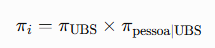

O segundo termo é uma probabilidade condicional: representa a probabilidade de selecionar aquela pessoa sabendo que sua UBS já foi selecionada.

### Exemplo teórico

Suponha que:
* uma UBS tenha 20% de probabilidade de ser selecionada
* uma vez selecionada a UBS, cada paciente tenha 10% de probabilidade de ser escolhido

Então, a probabilidade de determinado paciente chegar à amostra é:

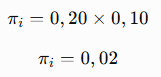

Portanto, esse paciente tinha 2% de probabilidade de ser incluído na amostra.

O peso amostral básico é o inverso dessa probabilidade:

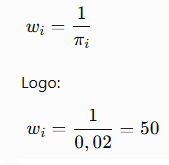

###  Como interpretar esse peso?

Didaticamente, podemos dizer que esse indivíduo representa aproximadamente 50 pessoas da população-alvo:

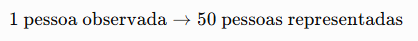

Isso acontece porque sua probabilidade de chegar à amostra era relativamente pequena.




> Intuição: quanto menor a probabilidade de uma pessoa ser selecionada, maior tende a ser seu peso amostral.



Em pesquisas reais, esse valor de 50 seria o peso básico do desenho. Ele ainda pode ser posteriormente ajustado por fatores como não resposta, calibração ou pós-estratificação.

###  Regra Geral

Quando a seleção ocorre em vários estágios, a probabilidade final de inclusão é construída a partir das probabilidades de seleção em cada etapa:

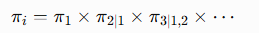

e o peso básico continua sendo:

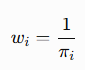

Assim, para compreender corretamente o peso de um indivíduo em uma pesquisa complexa, precisamos entender todo o caminho que ele percorreu até chegar à amostra.

## 🎯  Probabilidades desiguais, sobreamostragem e PPS

Mas nem todos precisam ter a mesma probabilidade de seleção.


#### Sobreamostragem

Imagine que idosos representem apenas 15% da população. Em uma amostra simples de 2.000 pessoas teríamos aproximadamente 300 idosos.

Se queremos estimativas precisas para idosos, podemos selecionar propositalmente:

- 1.000 adultos de 18 a 59 anos;
- 1.000 pessoas de 60 anos ou mais.

Agora 50% da amostra é idosa, embora somente 15% da população seja.

Isso **não é necessariamente um erro**. É uma decisão de desenho.

O erro ocorreria se analisássemos todos com contribuição igual e concluíssemos que a composição da amostra é a composição da população.

In [40]:
# ============================================================
# SOBREAMOSTRAGEM DE IDOSOS
# ============================================================

rng2 = np.random.default_rng(123)

mini_pop = pd.DataFrame({
    "grupo": np.repeat(
        ["18-59", "60+"],
        [85_000, 15_000]
    )
})

# Idosos têm maior prevalência de obesidade neste exemplo.
mini_pop["obesidade"] = np.r_[
    rng2.binomial(1, 0.20, 85_000), #tem 85.000 adultos
    rng2.binomial(1, 0.35, 15_000) #tem 15.000 idosos
]

mini_pop

,grupo,obesidade
0,18-59,0
1,18-59,0
2,18-59,0
3,18-59,0
4,18-59,0
...,...,...
99995,60+,1
99996,60+,0
99997,60+,0
99998,60+,0


In [41]:
# Selecionamos 1.000 de cada grupo.
amostra_over = pd.concat([
    mini_pop[mini_pop["grupo"] == "18-59"].sample(1000, random_state=1),
    mini_pop[mini_pop["grupo"] == "60+"].sample(1000, random_state=1)
]).copy()

amostra_over

,grupo,obesidade
76562,18-59,0
42148,18-59,1
57564,18-59,0
74611,18-59,0
58571,18-59,0
...,...,...
88167,60+,1
98129,60+,0
97749,60+,0
86160,60+,1


In [42]:
# Probabilidade de inclusão em cada grupo.
amostra_over["pi"] = amostra_over["grupo"].map({
    "18-59": 1000 / 85_000,
    "60+": 1000 / 15_000
})

amostra_over

,grupo,obesidade,pi
76562,18-59,0,0.011765
42148,18-59,1,0.011765
57564,18-59,0,0.011765
74611,18-59,0,0.011765
58571,18-59,0,0.011765
...,...,...,...
88167,60+,1,0.066667
98129,60+,0,0.066667
97749,60+,0,0.066667
86160,60+,1,0.066667


In [43]:
# Peso básico.
amostra_over["peso"] = 1 / amostra_over["pi"]
amostra_over

,grupo,obesidade,pi,peso
76562,18-59,0,0.011765,85.0
42148,18-59,1,0.011765,85.0
57564,18-59,0,0.011765,85.0
74611,18-59,0,0.011765,85.0
58571,18-59,0,0.011765,85.0
...,...,...,...,...
88167,60+,1,0.066667,15.0
98129,60+,0,0.066667,15.0
97749,60+,0,0.066667,15.0
86160,60+,1,0.066667,15.0


In [44]:
p_pop = mini_pop["obesidade"].mean()
p_sem_peso = amostra_over["obesidade"].mean()
p_com_peso = np.average(
    amostra_over["obesidade"],
    weights=amostra_over["peso"]
)

print(f"Verdade populacional: {p_pop:.3%}")
print(f"Sem peso:             {p_sem_peso:.3%}")
print(f"Com peso:             {p_com_peso:.3%}")

Verdade populacional: 22.123%
Sem peso:             28.200%
Com peso:             23.720%


A média simples fica elevada porque idosos, que possuem maior prevalência, estão super-representados.

Os pesos devolvem a cada grupo a contribuição compatível com sua probabilidade de seleção.


#### Probability Proportional to Size - PPS


Em seleção de conglomerados, unidades maiores podem receber maior probabilidade de seleção. Isso é **Probability Proportional to Size**, PPS.

Se uma escola possui 2.000 estudantes e outra possui 200, faz sentido que a primeira tenha maior chance de ser sorteada em certos desenhos.

PPS não deve ser interpretado isoladamente. A probabilidade final de uma pessoa depende da combinação do primeiro estágio com os estágios seguintes.

In [45]:
# ============================================================
# ILUSTRAÇÃO DE PPS
# ============================================================

exemplo_psu = pd.DataFrame({
    "PSU": ["A", "B", "C", "D", "E"],
    "tamanho": [100, 200, 400, 800, 1600]
})

exemplo_psu["prob_relativa"] = (
    exemplo_psu["tamanho"]
    / exemplo_psu["tamanho"].sum()
)

exemplo_psu

,PSU,tamanho,prob_relativa
0,A,100,0.032258
1,B,200,0.064516
2,C,400,0.129032
3,D,800,0.258065
4,E,1600,0.516129


### Atenção

PPS é um tema em que a fórmula exata da probabilidade de inclusão depende do algoritmo de seleção.

Por isso, em uma análise real, não devemos "inventar" a probabilidade a partir do tamanho observado.

O correto é usar as probabilidades ou pesos fornecidos pelo plano amostral.

## ⚖️ Pesos amostrais

Agora podemos consolidar o conceito.

O **peso básico** nasce da probabilidade de inclusão:


$$
w_i = \frac{1}{\pi_i}
$$

Quanto menor a probabilidade de inclusão, maior o peso.

Isso não significa que aquela pessoa seja clinicamente mais importante. Significa que sua observação representa uma parcela maior da população sob o desenho amostral.

Para uma variável $y_i$, uma média ponderada pode ser escrita como:

$$
\bar{y}_w =
\frac{\sum_i w_i y_i}
{\sum_i w_i}
$$

Se $y_i$ é binária, por exemplo:

- 1 = obesidade
- 0 = ausência de obesidade

então a média ponderada corresponde a uma prevalência ponderada:

$$
\hat{P}_w =
\frac{\sum_i w_i y_i}
{\sum_i w_i}
$$

De forma didática:

$$
\hat{P}_w =
\frac{\text{soma dos pesos de quem tem o desfecho}}
{\text{soma dos pesos de todos os indivíduos}}
$$



### Exemplo intuitivo

Suponha:

- adultos de 18 a 59 anos representam 85% da população;
- pessoas de 60+ representam 15%;
- queremos precisão entre idosos e fazemos uma amostra com 50% em cada grupo.

Isso não é necessariamente um erro.

É **sobreamostragem intencional**.

O erro seria analisar os dados como se metade da população realmente tivesse 60 anos ou mais.

In [46]:
# Pequena demonstração de oversampling
mini_pop = pd.DataFrame({
    "grupo": np.repeat(["18-59", "60+"], [85000, 15000])
})

rng2 = np.random.default_rng(123)
mini_pop["obesidade"] = np.r_[
    rng2.binomial(1, 0.20, 85000),
    rng2.binomial(1, 0.35, 15000)
]

amostra_over = pd.concat([
    mini_pop[mini_pop["grupo"] == "18-59"].sample(1000, random_state=1),
    mini_pop[mini_pop["grupo"] == "60+"].sample(1000, random_state=1)
])

amostra_over["peso"] = amostra_over["grupo"].map({
    "18-59": 85000 / 1000,
    "60+": 15000 / 1000
})

print("População verdadeira:", mini_pop["obesidade"].mean())
print("Amostra sem peso:", amostra_over["obesidade"].mean())
print("Amostra ponderada:", np.average(amostra_over["obesidade"], weights=amostra_over["peso"]))

População verdadeira: 0.22123
Amostra sem peso: 0.282
Amostra ponderada: 0.2372


### Regra mental

O peso responde aproximadamente à pergunta:

> "Quantas unidades da população esta observação representa sob o desenho e os ajustes realizados?"

Mas cuidado: pesos finais podem incluir muito mais do que apenas o inverso da probabilidade inicial.

### Peso básico versus peso final

Mas o peso disponibilizado em uma pesquisa real pode representar muito mais do que simplesmente:

$$
\frac{1}{\pi_i}
$$

Esse peso é chamado de **peso básico** porque é o ponto de partida. Em pesquisas reais, ele **pode depois ser ajustado por não resposta, pós-estratificação, calibração ou outros procedimentos**.

Um peso final pode resultar de várias etapas:

```text
Peso básico
    ↓
ajuste por não resposta
    ↓
ajuste de cobertura
    ↓
pós-estratificação / rake / calibração
    ↓
eventual trimming (eventual controle de pesos extremos)
    ↓
peso final
```

Por isso, quando uma pesquisa fornece um **peso final oficial**, normalmente devemos usar esse peso em vez de tentar reconstruí-lo sem necessidade.

## 📞 Não resposta

Em todo caso, mesmo com uma seleção probabilística perfeita, parte dos indivíduos selecionados pode não participar.

Se a não resposta ocorre de maneira diferente entre grupos, a composição da amostra respondente muda.

A pessoa pode ser selecionada corretamente e, ainda assim, não participar.

Isso cria um novo mecanismo de seleção:

1. ser selecionado;
2. responder.


### Exemplo de não resposta


Imagine que foram selecionados:

- 1.000 adultos jovens;
- 1.000 idosos.

Responderam:

- 400 jovens;
- 850 idosos.

Se o comportamento de saúde difere por idade, usar os mesmos pesos básicos pode deixar a amostra respondente desequilibrada.

Uma estratégia é ajustar os pesos em **células de não resposta**, desde que existam informações adequadas para isso.

### Ajuste simples por não resposta

Depois de calcular o peso básico, ainda existe outro problema possível: algumas pessoas selecionadas para a amostra podem não responder à pesquisa.

Isso importa porque os respondentes podem ter características diferentes dos não respondentes.

Imagine, por exemplo, que pessoas mais jovens sejam mais difíceis de localizar ou tenham menor probabilidade de responder a um inquérito de saúde. Se simplesmente analisarmos apenas quem respondeu, esse grupo pode ficar sub-representado.

Uma estratégia é aumentar o peso dos indivíduos que responderam, para que eles também representem parte dos indivíduos semelhantes que foram selecionados, mas não responderam.

### Cálculo Teórico

Primeiro, dividimos os indivíduos em grupos ou células de ajuste com características relacionadas à probabilidade de resposta.

Por exemplo:
- faixa etária
- sexo
- região
- escolaridade


Dentro de cada célula c, podemos calcular um fator de ajuste:

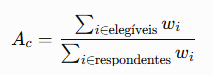

O numerador representa o peso total de todas as pessoas elegíveis daquela célula. O denominador representa o peso total apenas das pessoas que efetivamente responderam. Depois, multiplicamos o peso básico dos respondentes pelo fator de ajuste:

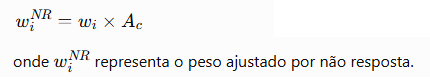

### Cálculo de Exemplo

Imagine uma determinada faixa etária em que foram selecionadas 100 pessoas, todas inicialmente com peso 10. O peso total dos elegíveis seria:

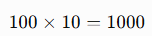

Entretanto, apenas 80 pessoas responderam. O peso total dos respondentes antes do ajuste seria:

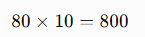

O fator de ajuste seria:

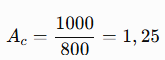

Assim, o novo peso de cada respondente desse grupo seria:

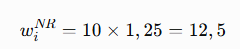

Assim, antes do ajuste:

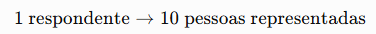

Depois do ajuste:

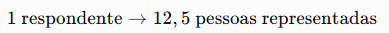

Ou seja, o peso dos respondentes aumenta porque eles agora precisam representar também parte das pessoas daquele grupo que não responderam.

> Intuição: o ajuste por não resposta redistribui o peso dos indivíduos que não responderam entre indivíduos semelhantes que responderam.


Esse procedimento depende de uma hipótese importante: dentro das células utilizadas para o ajuste, os respondentes devem ser razoavelmente representativos dos não respondentes.
Na prática, pesquisas podem utilizar métodos mais sofisticados para estimar a probabilidade de resposta, mas a lógica central permanece a mesma.

## 🎓 Pós-estratificação, rake e calibração

Até este ponto, construímos os pesos a partir do próprio processo de amostragem.

Primeiro surgiu o peso básico, definido pela probabilidade de inclusão:

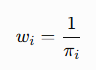

Depois, esse peso pôde ser ajustado para compensar a não resposta.

Mesmo após esses ajustes, porém, a população representada pela amostra pode continuar apresentando uma composição diferente daquela que sabemos existir na população real.

Imagine um inquérito de saúde em uma cidade.

Depois de aplicar o peso básico e o ajuste por não resposta, verificamos que a população representada pela amostra é:

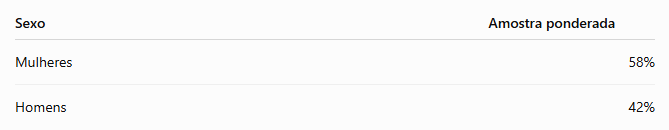

Entretanto, dados populacionais confiáveis informam que a cidade possui:

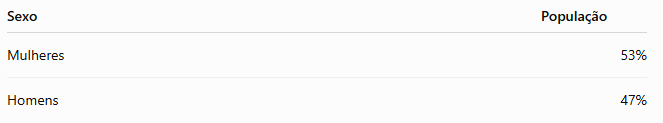

Portanto, mesmo depois dos ajustes anteriores, as mulheres continuam sobre-representadas e os homens sub-representados.

Isso pode ser importante se o desfecho que estamos estudando estiver associado ao sexo.

Por exemplo, se a prevalência de determinado fator de risco for diferente entre homens e mulheres, essa diferença de composição pode afetar a estimativa populacional final.

A ideia dos procedimentos que veremos agora é:



> usar informações conhecidas sobre a população para realizar novos ajustes nos pesos, fazendo com que a população representada pela amostra se aproxime dessas características conhecidas.



Existem diferentes maneiras de fazer isso. Três conceitos importantes são:

* pós-estratificação;
* rake;
* calibração.

Eles estão relacionados, mas não são exatamente a mesma coisa.

### Pós-Estratificação

Na pós-estratificação, conhecemos o tamanho populacional de combinações completas de categorias.

Imagine que conheçamos a distribuição populacional conjunta de sexo e faixa etária:

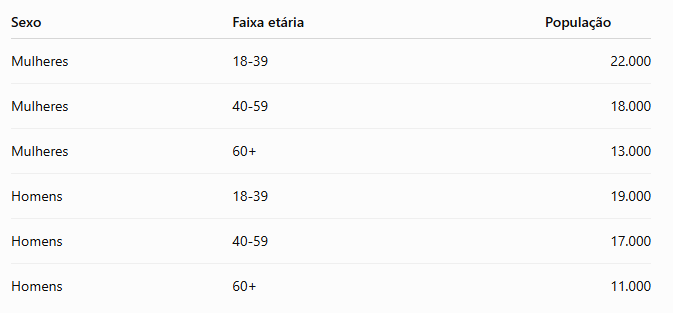

Nesse caso, sabemos não apenas:
* quantas mulheres existem;
* quantos homens existem;
* quantas pessoas jovens existem;
* quantas pessoas idosas existem.

Sabemos também quantas pessoas existem em cada combinação entre sexo e idade. Por exemplo:

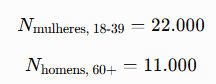

Podemos então ajustar os pesos dentro de cada uma dessas células para que a soma dos pesos corresponda ao total populacional conhecido.

Exemplo: Suponha que, depois dos pesos atuais, os respondentes do grupo homens com 60 anos ou mais representem apenas 8.800 pessoas. Mas sabemos que existem 11.000. O fator de ajuste seria:

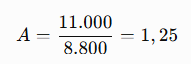

Os pesos das pessoas pertencentes a essa célula seriam multiplicados por 1,25. Se uma dessas pessoas possuía peso 20:

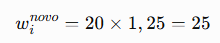

Ela passa a representar 25 pessoas em vez de 20. A lógica é fazer com que:

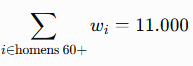

Um ponto importante: Estratificação e pós-estratificação são conceitos diferentes. Na estratificação, dividimos a população antes da seleção da amostra e realizamos o sorteio dentro desses grupos. Na pós-estratificação, os grupos são utilizados depois da coleta, para ajustar os pesos utilizando totais populacionais conhecidos.

### Rake

O problema é que nem sempre possuímos uma tabela populacional completa com todas as combinações.

Podemos conhecer separadamente:
- sexo;
- idade;
- escolaridade.

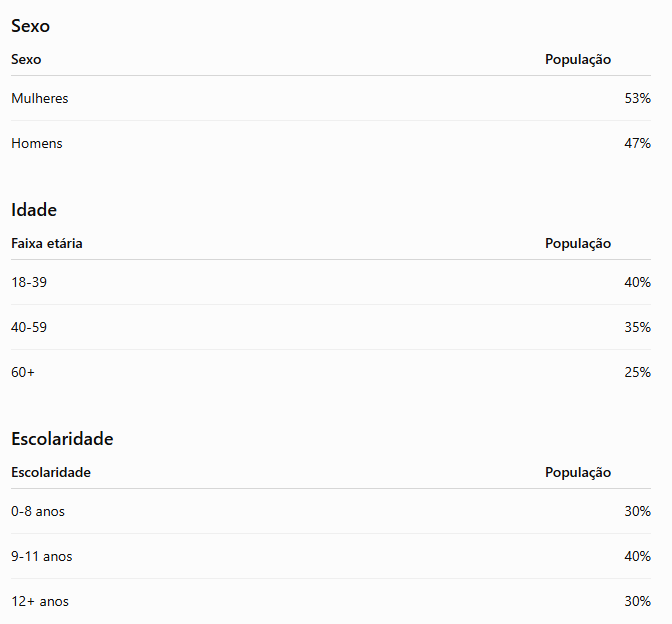

Mas talvez não saibamos exatamente quantas pessoas pertencem simultaneamente a cada combinação:

* mulher, 18-39 anos, 12+ anos de estudo;
* homem, 60+, 0-8 anos de estudo;
* mulher, 40-59, 9-11 anos de estudo;
* e assim por diante.

Em outras palavras, conhecemos as margens populacionais, mas não necessariamente a distribuição conjunta completa.

É justamente nessa situação que o rake, ou raking, é muito útil.

Mas o que significa margem? Imagine uma tabela cruzando sexo e idade:

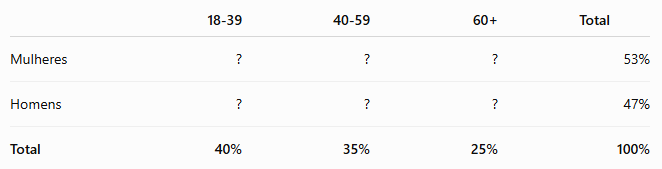

Conhecemos os totais das linhas:
* 53% mulheres;
* 47% homens.

E os totais das colunas:
* 40% de 18-39;
* 35% de 40-59;
* 25% de 60+.

Esses totais localizados nas bordas da tabela são as margens.

Mas não conhecemos necessariamente os valores das células internas.

O rake, então, modifica os pesos de forma iterativa. Imagine que, depois do peso básico e do ajuste por não resposta, nossa amostra ponderada apresente:

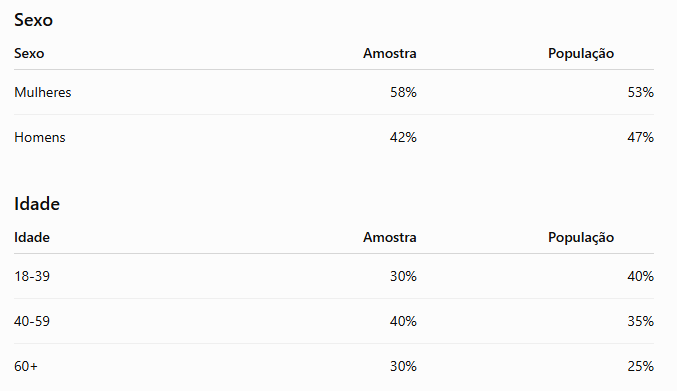

O rake pode começar ajustando os pesos para sexo. Depois do primeiro ajuste:

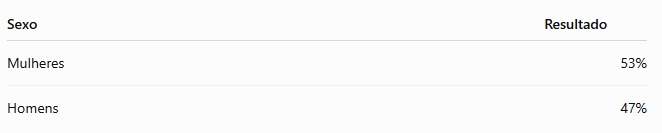

Mas ainda precisamos corrigir a idade. O algoritmo então modifica novamente os pesos para obter:

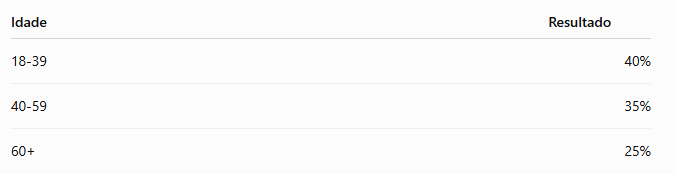

Surge então um detalhe importante. As mesmas pessoas possuem simultaneamente:
* sexo;
* idade;
* escolaridade.

Quando modificamos seus pesos para corrigir a idade, podemos alterar novamente um pouco a distribuição de sexo.

Por exemplo:

Depois do ajuste de idade, poderíamos ficar com:

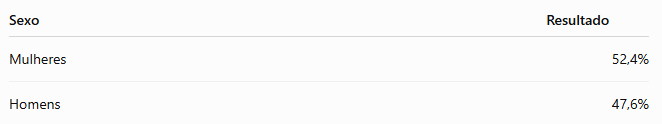

Agora sexo deixou de coincidir exatamente com a margem desejada. O algoritmo volta e ajusta sexo novamente. Depois ajusta idade novamente. Se também houver escolaridade, ajusta escolaridade. O processo pode ser representado assim:

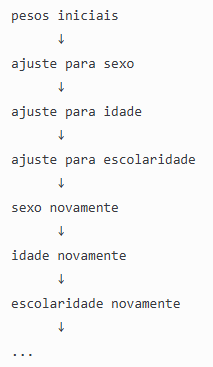

O procedimento continua até que as diferenças entre as distribuições ponderadas e as margens populacionais sejam suficientemente pequenas. Por isso o rake é um procedimento iterativo.

Mas um detalhe importante: O rake não cria novas pessoas. Se a pesquisa possui 2.000 respondentes, ela continua possuindo exatamente 2.000 respondentes. O que muda é quanto cada respondente representa. Imagine duas pessoas:

* Pessoa A: mulher; 60 anos ou mais; ensino superior. Peso antes do rake: 18. Depois do rake: 14
* Pessoa B: homem; 18-39 anos; baixa escolaridade. Peso antes do rake: 16. Depois do rake: 23

Isso poderia acontecer se características semelhantes às da Pessoa A estivessem relativamente muito representadas na amostra, enquanto pessoas semelhantes à Pessoa B estivessem pouco representadas.

A Pessoa B passa, então, a contribuir mais para as estimativas populacionais.

Em todo caso, é importante dizer: O rake é útil, mas não possui capacidade de corrigir qualquer problema de representatividade.

Suponha que ajustemos os pesos para:
* sexo;
* idade;
* escolaridade.

Depois do rake, a população ponderada reproduz perfeitamente essas três características.

Isso não garante que ela também reproduza corretamente:
* renda;
* raça/cor;
* presença de doença crônica;
* acesso aos serviços;
* comportamento de saúde;
* outras características não utilizadas no ajuste.

Portanto, o rake melhora a representação em relação às variáveis utilizadas, mas não transforma automaticamente uma amostra problemática em uma representação perfeita da população.

A escolha das margens é importante. Idealmente, as variáveis utilizadas devem:
* possuir totais populacionais externos confiáveis;
* estar relacionadas à seleção ou à não resposta;
* e, preferencialmente, também estar relacionadas aos desfechos de interesse.

### Calibração



A calibração é uma ideia mais geral. Partimos de pesos já existentes: wi​ e e procuramos novos pesos wi∗ que satisfaçam simultaneamente duas condições.

* Condição 1: Os novos pesos devem permanecer razoavelmente próximos dos pesos originais. Não queremos reconstruir completamente o desenho. Queremos apenas realizar o ajuste necessário.

* Condição 2: Os novos pesos devem fazer determinadas quantidades ponderadas coincidirem com informações populacionais conhecidas. De maneira conceitual:

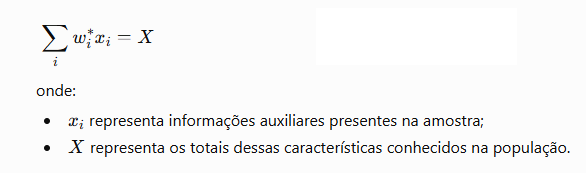

Para exemplificarmos isso: Suponha que saibamos que a população possui 53.000 mulheres e 47.000 homens. Queremos que os pesos finais satisfaçam:

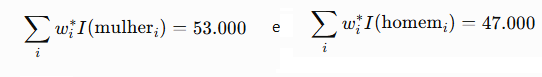

Ou seja, depois da calibração, se somarmos os pesos das mulheres da amostra, queremos recuperar aproximadamente o número conhecido de mulheres na população.

### Relação entre pós-estratificação, rake e calibração


A ideia comum aos três métodos é aproveitar informações externas confiáveis sobre a população para melhorar a correspondência entre a população representada pelos pesos e a população que queremos estudar.

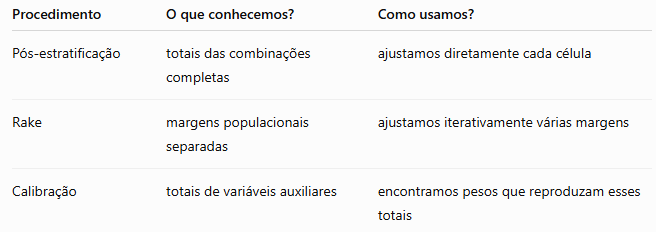

### Pesos extremos e trimming

Quanto mais precisamos corrigir a representação, maior pode ser a dispersão dos pesos.

Pesos muito grandes podem aumentar a variância e fazer poucas observações dominarem uma estimativa.

Algumas metodologias utilizam **trimming**, limitando pesos extremos e posteriormente recalibrando.

Isso envolve uma troca entre:

- reduzir influência excessiva e variância;
- introduzir alguma alteração na representação original.

Por isso trimming não deve ser usado automaticamente. Deve seguir a metodologia da pesquisa ou análise de sensibilidade explicitamente justificada.

## 📈 Variância, ICC, DEFF, tamanho efetivo e FPC

Até agora perguntamos principalmente:

> Quem cada pessoa representa?

Agora a pergunta é:

> Quanta informação independente existe na amostra?

Uma análise pode ter estimativa pontual razoável e intervalo de confiança incorreto.

De forma didática:

- pesos podem modificar a estimativa pontual e também a variância;
- conglomerados geralmente aumentam a variância por causa da dependência interna;
- estratos bem escolhidos podem reduzir a variância;
- pesos muito desiguais podem reduzir eficiência;
- FPC pode reduzir a variância quando uma grande fração da população é observada.

### Design Effect

O **efeito de desenho**, ou $DEFF$, compara a variância obtida sob o desenho amostral utilizado com a variância de uma situação de referência, geralmente uma amostra aleatória simples.

$$
DEFF =
\frac{
\operatorname{Var}_{\text{desenho}}(\hat{\theta})
}{
\operatorname{Var}_{\text{referência}}(\hat{\theta})
}
$$

A interpretação é:

- $DEFF = 1$: precisão semelhante à referência
- $DEFF > 1$: maior variância e, portanto, menor precisão
- $DEFF < 1$: menor variância e, portanto, maior precisão

Por exemplo, se:

$$
DEFF = 2
$$

isso significa que a variância da estimativa é aproximadamente **duas vezes maior** do que seria sob o desenho de referência.

O $DEFF$ não é necessariamente uma propriedade única e fixa de uma pesquisa. Ele pode variar conforme:

- a variável analisada
- o domínio ou subgrupo estudado
- o estimador utilizado
- a estrutura de conglomerados e estratos
- a distribuição dos pesos amostrais

Por isso, uma mesma pesquisa pode apresentar valores diferentes de $DEFF$ dependendo da análise realizada.

In [47]:
# ============================================================
# INTUIÇÃO DO EFEITO DO CONGLOMERADO
# ============================================================

def deff_cluster(m, rho):
    # Aproximação: DEFF = 1 + (m - 1) * ICC
    return 1 + (m - 1) * rho

cenarios = pd.DataFrame({
    "tamanho_medio_cluster": [10, 25, 50, 100],
    "ICC": [0.02, 0.02, 0.02, 0.02]
})

cenarios["DEFF_aproximado"] = [
    deff_cluster(m, rho)
    for m, rho in zip(
        cenarios["tamanho_medio_cluster"],
        cenarios["ICC"]
    )
]

cenarios

,tamanho_medio_cluster,ICC,DEFF_aproximado
0,10,0.02,1.18
1,25,0.02,1.48
2,50,0.02,1.98
3,100,0.02,2.98


### Coeficiente de correlação intraclasse - ICC

O **ICC, coeficiente de correlação intraclasse**, expressa quanto indivíduos pertencentes ao mesmo conglomerado tendem a se parecer.

Em um cenário simples, uma aproximação útil para o efeito do desenho causado pela clusterização é:

$$
DEFF_{\text{cluster}} \approx 1 + (m - 1)\rho
$$

onde:

- $m$ é o tamanho médio do conglomerado
- $\rho$ é o ICC

Suponha:

$$
m = 50
$$

e:

$$
\rho = 0{,}02
$$

Então:

$$
DEFF_{\text{cluster}}
\approx
1 + (50 - 1)\times 0{,}02
$$

$$
DEFF_{\text{cluster}}
\approx
1 + 49\times 0{,}02
=
1{,}98
$$

Portanto, mesmo um ICC aparentemente pequeno pode produzir um efeito importante quando muitos indivíduos são observados dentro de cada conglomerado.

Neste exemplo, um $DEFF$ de aproximadamente **1,98** indica que a variância da estimativa é quase duas vezes maior do que seria esperada em uma amostra aleatória simples de mesmo tamanho.

### Tamanho amostral efetivo


O **tamanho amostral efetivo** traduz a precisão obtida com um desenho amostral complexo para o tamanho de uma amostra aleatória simples que produziria precisão semelhante.

Uma aproximação útil é:

$$
n_{\text{efetivo}} \approx \frac{n}{DEFF}
$$

Suponha:

$$
n = 2.000
$$

e:

$$
DEFF = 2
$$

Então:

$$
n_{\text{efetivo}}
\approx
\frac{2.000}{2}
=
1.000
$$

Isso **não significa que metade dos registros desapareceu**. Os 2.000 indivíduos continuam presentes na base.

O que essa medida indica é que, devido ao desenho amostral, a precisão da estimativa é aproximadamente equivalente àquela que seria obtida com uma amostra aleatória simples de **1.000 indivíduos**.



### Efeito da desigualdade dos pesos

Existe também uma medida de tamanho amostral efetivo relacionada especificamente à **variabilidade dos pesos amostrais**, conhecida como tamanho amostral efetivo de Kish:

$$
n_{\text{eff,w}}
=
\frac{
\left(\sum_i w_i\right)^2
}{
\sum_i w_i^2
}
$$

Se todos os indivíduos possuem pesos iguais:

$$
n_{\text{eff,w}} = n
$$

À medida que os pesos se tornam mais desiguais, o tamanho amostral efetivo tende a diminuir.

Isso acontece porque algumas observações passam a contribuir muito mais para a estimativa do que outras, reduzindo a quantidade efetiva de informação disponível.

### Correção para população finita

Quando selecionamos uma fração grande de uma população finita, a incerteza da estimativa diminui.

Em uma **amostra aleatória simples sem reposição**, a correção para população finita pode ser expressa por:

$$
FPC =
\sqrt{
\frac{N-n}{N-1}
}
$$

onde:

- $N$ é o tamanho total da população
- $n$ é o tamanho da amostra

Por exemplo, imagine uma população com:

$$
N = 100
$$

e uma amostra de:

$$
n = 80
$$

Nesse caso:

$$
FPC
=
\sqrt{
\frac{100-80}{100-1}
}
=
\sqrt{
\frac{20}{99}
}
\approx
0{,}45
$$

Isso significa que o erro-padrão pode ser multiplicado por aproximadamente **0,45**, refletindo a grande quantidade de informação obtida ao observar 80% daquela população.

Selecionar **80 pessoas de uma população de 100** fornece muito mais informação sobre aquela população específica do que selecionar 80 pessoas de uma população de milhões.

Quando a fração amostral:

$$
\frac{n}{N}
$$

é muito pequena, temos aproximadamente:

$$
FPC \approx 1
$$

e a correção exerce pouco efeito sobre a precisão.

Em desenhos amostrais complexos, a correção para população finita pode aparecer em diferentes estágios da seleção. Por isso, deve ser aplicada de acordo com a estrutura e a documentação do plano amostral.

## 🏗️ Construindo uma pesquisa complexa completa em Python

Agora juntaremos os conceitos em uma única pesquisa simulada.

O desenho terá:

1. estratificação por região;
2. seleção de 8 PSUs entre 20 em cada região;
3. seleção de pessoas dentro das PSUs;
4. maior probabilidade de seleção para idosos;
5. não resposta diferente por idade e sexo;
6. cálculo do peso básico;
7. ajuste por não resposta.

Assim veremos o peso nascer passo a passo.

In [67]:
# ============================================================
# ETAPA 1 - PSUs DENTRO DOS ESTRATOS
# ============================================================

rng_amostra = np.random.default_rng(SEED)

psus_pop = (
    pop[["regiao", "psu"]]
    .drop_duplicates()
    .sort_values(["regiao", "psu"])
)

selecionadas = []

for regiao, grupo in psus_pop.groupby("regiao"):
    psus = grupo["psu"].to_numpy()

    escolhidas = rng_amostra.choice(
        psus,
        size=8,
        replace=False
    )

    selecionadas.extend(
        [(regiao, psu) for psu in escolhidas]
    )

psus_sel = pd.DataFrame(
    selecionadas,
    columns=["regiao", "psu"]
)

# 8 de 20 PSUs por região.
psus_sel["pi_psu"] = 8 / psus_por_regiao

base_psus = pop.merge(
    psus_sel,
    on=["regiao", "psu"],
    how="inner"
)

print("PSUs selecionadas:", len(psus_sel))
print("Pessoas nas PSUs selecionadas:", len(base_psus))

PSUs selecionadas: 32
Pessoas nas PSUs selecionadas: 49352


In [68]:
# ============================================================
# ETAPA 2 - SELEÇÃO DAS PESSOAS
# ============================================================

base_psus = base_psus.copy()

base_psus["faixa_idade"] = pd.cut(
    base_psus["idade"],
    bins=[17, 39, 59, 200],
    labels=["18-39", "40-59", "60+"]
)

# Probabilidade condicional de seleção da pessoa
# sabendo que a PSU foi selecionada.
prob_pessoa = {
    "18-39": 0.08,
    "40-59": 0.10,
    "60+": 0.22
}

base_psus["pi_pessoa_cond"] = (
    base_psus["faixa_idade"]
    .astype(str)
    .map(prob_pessoa)
)

rng_pessoa = np.random.default_rng(SEED + 1)

foi_selecionado = (
    rng_pessoa.random(len(base_psus))
    < base_psus["pi_pessoa_cond"]
)

selecionados = base_psus.loc[foi_selecionado].copy()

# Probabilidade final = primeiro estágio × segundo estágio.
selecionados["pi_inclusao"] = (
    selecionados["pi_psu"]
    * selecionados["pi_pessoa_cond"]
)

# Peso básico.
selecionados["peso_base"] = (
    1 / selecionados["pi_inclusao"]
)

print("Selecionados antes da não resposta:", len(selecionados))
print(selecionados["faixa_idade"].value_counts(normalize=True).sort_index())

Selecionados antes da não resposta: 5954
faixa_idade
18-39    0.222204
40-59    0.375546
60+      0.402251
Name: proportion, dtype: float64


Observe dois participantes:

**18-39 anos**

A probabilidade de inclusão é:

$$
\pi_i = 0{,}40 \times 0{,}08 = 0{,}032
$$

O peso amostral correspondente é:

$$
w_i = \frac{1}{0{,}032} = 31{,}25
$$

**60 anos ou mais**

A probabilidade de inclusão é:

$$
\pi_i = 0{,}40 \times 0{,}22 = 0{,}088
$$

O peso amostral correspondente é:

$$
w_i = \frac{1}{0{,}088} \approx 11{,}36
$$

O participante idoso apresenta maior probabilidade de inclusão na amostra. Por isso, seu peso amostral é menor.

Didaticamente:

- cada participante de **18-39 anos** representa aproximadamente **31,25 pessoas**
- cada participante de **60 anos ou mais** representa aproximadamente **11,36 pessoas**

Isso mostra a relação inversa entre probabilidade de inclusão e peso amostral:

$$
w_i = \frac{1}{\pi_i}
$$

Quanto maior a probabilidade de uma pessoa ser selecionada, menor será o peso necessário para que ela represente adequadamente a população.

In [69]:
# ============================================================
# ETAPA 3 - SIMULAÇÃO DA NÃO RESPOSTA
# ============================================================

# Probabilidade inicial de resposta.
p_resposta = np.full(
    len(selecionados),
    0.88,
    dtype=float
)

# Jovens respondem menos.
p_resposta -= (
    0.15
    * (selecionados["faixa_idade"].astype(str) == "18-39")
)

# Homens respondem um pouco menos.
p_resposta -= (
    0.08
    * (selecionados["sexo"] == "Masculino")
)

p_resposta = np.clip(p_resposta, 0.50, 0.95)

rng_resposta = np.random.default_rng(SEED + 2)

respondeu = (
    rng_resposta.random(len(selecionados))
    < p_resposta
)

amostra_complexa = selecionados.loc[respondeu].copy()

print("Selecionados:", len(selecionados))
print("Respondentes:", len(amostra_complexa))
print(
    "Taxa de resposta:",
    f"{len(amostra_complexa)/len(selecionados):.1%}"
)

Selecionados: 5954
Respondentes: 4807
Taxa de resposta: 80.7%


In [71]:
# ============================================================
# ETAPA 4 - AJUSTE POR NÃO RESPOSTA
# ============================================================

# Criamos células faixa etária × sexo.
selecionados["celula_nr"] = (
    selecionados["faixa_idade"].astype(str)
    + " | "
    + selecionados["sexo"]
)

amostra_complexa["celula_nr"] = (
    amostra_complexa["faixa_idade"].astype(str)
    + " | "
    + amostra_complexa["sexo"]
)

# Peso que deveria ser representado em cada célula.
peso_elegiveis = (
    selecionados
    .groupby("celula_nr")["peso_base"]
    .sum()
)

# Peso representado apenas pelos respondentes.
peso_respondentes = (
    amostra_complexa
    .groupby("celula_nr")["peso_base"]
    .sum()
)

# Fator de ajuste.
fator_nr = peso_elegiveis / peso_respondentes

amostra_complexa["fator_nr"] = (
    amostra_complexa["celula_nr"]
    .map(fator_nr)
)

# Peso após ajuste de não resposta.
amostra_complexa["peso_nr"] = (
    amostra_complexa["peso_base"]
    * amostra_complexa["fator_nr"]
)

amostra_complexa[[
    "regiao",
    "psu",
    "faixa_idade",
    "sexo",
    "pi_inclusao",
    "peso_base",
    "fator_nr",
    "peso_nr"
]].head()

,regiao,psu,faixa_idade,sexo,pi_inclusao,peso_base,fator_nr,peso_nr
1,Oeste,O_08,40-59,Feminino,0.040,25.00,1.139692,28.492293
2,Sul,S_07,40-59,Masculino,0.040,25.00,1.253571,31.339286
15,Leste,L_09,18-39,Masculino,0.032,31.25,1.546154,48.317308
32,Norte,N_18,18-39,Feminino,0.032,31.25,1.368821,42.775665
45,Sul,S_10,40-59,Masculino,0.040,25.00,1.253571,31.339286


In [72]:
# ============================================================
# O QUE ACONTECE SE IGNORARMOS O DESENHO?
# ============================================================

prev_verdadeira = pop["obesidade"].mean()

prev_bruta = (
    amostra_complexa["obesidade"].mean()
)

prev_ponderada = np.average(
    amostra_complexa["obesidade"],
    weights=amostra_complexa["peso_nr"]
)

comparacao = pd.DataFrame({
    "resultado": [
        "População verdadeira",
        "Respondentes sem peso",
        "Respondentes com peso"
    ],
    "prevalencia": [
        prev_verdadeira,
        prev_bruta,
        prev_ponderada
    ]
})

comparacao

,resultado,prevalencia
0,População verdadeira,0.159158
1,Respondentes sem peso,0.187851
2,Respondentes com peso,0.164083


### Interpretação

A prevalência bruta descreve os **respondentes observados**.

A prevalência ponderada tenta reconstruir a **população representada pelo desenho**.

Essa distinção é uma das ideias mais importantes da aula.

Mas ainda falta algo: a média ponderada por si só não informa corretamente toda a incerteza produzida por estratos e PSUs. Para isso usaremos o pacote `survey`.

## 💻 Preparando R dentro do Google Colab



Continuaremos trabalhando no mesmo notebook.

Execute a próxima célula apenas em um ambiente novo. Ela verifica se o R existe, instala-o se necessário e instala `rpy2`, que permite executar células R dentro de um notebook Python.

In [14]:
# ============================================================
# PREPARAÇÃO DO AMBIENTE R
# ============================================================

import shutil
import subprocess
import sys

if shutil.which("R") is None:
    print("R não encontrado. Instalando...")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "r-base", "r-base-dev"],
        check=True
    )
else:
    print("R já está disponível.")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "rpy2"],
    check=True
)

print("Preparação concluída.")

R já está disponível.
Preparação concluída.


In [15]:
# Habilita as magics %R e %%R.
%load_ext rpy2.ipython

In [16]:
%%R

if (!requireNamespace("survey", quietly = TRUE)) {
    install.packages(
        "survey",
        repos = "https://cloud.r-project.org"
    )
}

library(survey)

packageVersion("survey")

[1] ‘4.5’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘minqa’, ‘numDeriv’, ‘mitools’, ‘RcppArmadillo’

trying URL 'https://cloud.r-project.org/src/contrib/minqa_1.2.8.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/numDeriv_2016.8-1.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/mitools_2.4.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/RcppArmadillo_15.4.2-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/survey_4.5.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpXnzoZJ/downloaded_packages’
Loading required package: grid
Loading required package: Matrix
Loading required package: survival

Attaching package: ‘survey’

The following object is masked from ‘package:graphics’:

    dotchart



## ⬜ Construindo o desenho com `survey`


O DataFrame contém linhas de indivíduos.

O R precisa saber **como essas linhas foram produzidas**.

No nosso exemplo:

- estrato: `regiao`;
- PSU: `psu`;
- peso atual: `peso_nr`.

Antes de construir o desenho, também criaremos margens populacionais de sexo e faixa etária, que serão usadas posteriormente no rake.

In [53]:
# ============================================================
# MARGENS POPULACIONAIS CONHECIDAS
# ============================================================

pop_aux = pop.copy()

pop_aux["faixa_idade"] = pd.cut(
    pop_aux["idade"],
    bins=[17, 39, 59, 200],
    labels=["18-39", "40-59", "60+"]
)

pop_sexo = (
    pop_aux
    .groupby("sexo", observed=True)
    .size()
    .reset_index(name="Freq")
)

pop_idade = (
    pop_aux
    .groupby("faixa_idade", observed=True)
    .size()
    .reset_index(name="Freq")
)

display(pop_sexo)
display(pop_idade)

,sexo,Freq
0,Feminino,64077
1,Masculino,55923


,faixa_idade,Freq
0,18-39,40950
1,40-59,52597
2,60+,26453


In [54]:
%%R -i amostra_complexa -i pop_sexo -i pop_idade

cat("Respondentes recebidos no R:", nrow(amostra_complexa), "\n")
head(amostra_complexa)

Respondentes recebidos no R: 4807 
    id regiao  psu idade      sexo escolaridade obesidade hipertensao diabetes
1    7  Oeste O_08  48.9  Feminino     12+ anos         0           0        0
2    8    Sul S_07  49.2 Masculino     0-8 anos         0           0        0
15  52  Leste L_09  18.0 Masculino     0-8 anos         1           0        0
32  95  Norte N_18  21.9  Feminino     12+ anos         0           0        0
45 121    Sul S_10  40.2 Masculino     0-8 anos         0           0        0
54 141  Leste L_01  28.2 Masculino    9-11 anos         0           0        0
   pi_psu faixa_idade pi_pessoa_cond pi_inclusao peso_base         celula_nr
1     0.4       40-59           0.10       0.040     25.00  40-59 | Feminino
2     0.4       40-59           0.10       0.040     25.00 40-59 | Masculino
15    0.4       18-39           0.08       0.032     31.25 18-39 | Masculino
32    0.4       18-39           0.08       0.032     31.25  18-39 | Feminino
45    0.4       40-59      

### `svydesign()`

```r
design_base <- svydesign(
    ids = ~psu,
    strata = ~regiao,
    weights = ~peso_nr,
    data = amostra_complexa,
    nest = TRUE
)
```

Cada argumento tem significado:

- `ids = ~psu`: informa a unidade primária de amostragem;
- `strata = ~regiao`: informa que a seleção foi organizada separadamente dentro das regiões;
- `weights = ~peso_nr`: informa a contribuição atual de cada respondente;
- `data = amostra_complexa`: fornece os registros;
- `nest = TRUE`: permite tratar corretamente identificadores de PSU aninhados em estratos.

O objeto `svydesign()` não é apenas um DataFrame com peso. É uma representação do mecanismo amostral necessário para estimar parâmetros e variâncias.

In [55]:
%%R

# Para a simulação, usamos uma estratégia explícita para eventual lonely PSU.
# Em uma pesquisa real, a escolha deve seguir a documentação metodológica.
options(survey.lonely.psu = "adjust")

design_base <- svydesign(
    ids = ~psu,
    strata = ~regiao,
    weights = ~peso_nr,
    data = amostra_complexa,
    nest = TRUE
)

design_base

Stratified 1 - level Cluster Sampling design (with replacement)
With (32) clusters.
svydesign(ids = ~psu, strata = ~regiao, weights = ~peso_nr, data = amostra_complexa, 
    nest = TRUE)


### Aplicando rake



O peso atual já incorpora seleção e não resposta.

Agora ajustaremos as margens para reproduzir os totais populacionais de sexo e faixa etária.

In [57]:
%%R

# Harmonizamos categorias.
amostra_complexa$sexo <- factor(amostra_complexa$sexo)

amostra_complexa$faixa_idade <- factor(
    amostra_complexa$faixa_idade,
    levels = c("18-39", "40-59", "60+")
)

pop_sexo$sexo <- factor(pop_sexo$sexo)

pop_idade$faixa_idade <- factor(
    pop_idade$faixa_idade,
    levels = c("18-39", "40-59", "60+")
)

# Reconstruímos o desenho depois das conversões de fatores.
design_base <- svydesign(
    ids = ~psu,
    strata = ~regiao,
    weights = ~peso_nr,
    data = amostra_complexa,
    nest = TRUE
)

design_rake <- rake(
    design = design_base,
    sample.margins = list(
        ~sexo,
        ~faixa_idade
    ),
    population.margins = list(
        pop_sexo,
        pop_idade
    )
)

design_rake

Stratified 1 - level Cluster Sampling design (with replacement)
With (32) clusters.
rake(design = design_base, sample.margins = list(~sexo, ~faixa_idade), 
    population.margins = list(pop_sexo, pop_idade))


In [58]:
%%R

# Uma calibração deve ser verificada.
cat("Totais ponderados por sexo:\n")
print(svytable(~sexo, design_rake))

cat("\nTotais ponderados por faixa etária:\n")
print(svytable(~faixa_idade, design_rake))

Totais ponderados por sexo:
sexo
 Feminino Masculino 
    64077     55923 

Totais ponderados por faixa etária:
faixa_idade
18-39 40-59   60+ 
40950 52597 26453 


### Estimativas, intervalos e domínios



Agora finalmente utilizaremos o desenho completo.

Para uma variável binária como obesidade, `svymean()` calcula sua média ponderada. Como a variável é 0/1, a média é a prevalência.

In [59]:
%%R

prev_obesidade <- svymean(
    ~obesidade,
    design_rake
)

prev_obesidade

             mean     SE
obesidade 0.16387 0.0091


In [60]:
%%R

# Intervalo de confiança calculado usando a variância do desenho.
confint(prev_obesidade)

              2.5 %   97.5 %
obesidade 0.1460329 0.181712


### Por que isso é diferente de apenas usar uma média ponderada?



Em Python, podemos calcular uma média ponderada por:

$$
\bar{y}_w =
\frac{\sum_i w_i y_i}
{\sum_i w_i}
$$

e obter uma boa **estimativa pontual**.

Mas essa operação, sozinha, não informa ao software:

- quais pessoas pertencem à mesma PSU
- em quais estratos as PSUs foram selecionadas
- quantas unidades independentes existem para estimar a variância

Por isso, considerar apenas os pesos pode ser suficiente para obter a estimativa pontual, mas não para calcular corretamente sua incerteza.

O principal ganho de um objeto de **survey** aparece justamente na estimativa adequada de:

- erro-padrão
- intervalo de confiança
- variância
- testes de hipótese

Isso acontece porque o objeto incorpora a estrutura do desenho amostral, e não apenas os pesos.

In [61]:
# ============================================================
# COMPARAÇÃO PONTUAL
# ============================================================

p_naive = amostra_complexa["obesidade"].mean()

p_weighted_nr = np.average(
    amostra_complexa["obesidade"],
    weights=amostra_complexa["peso_nr"]
)

print(f"Sem peso:             {p_naive:.3%}")
print(f"Com peso NR:          {p_weighted_nr:.3%}")
print(f"Verdade populacional: {pop['obesidade'].mean():.3%}")

Sem peso:             18.785%
Com peso NR:          16.408%
Verdade populacional: 15.916%


### Estimativas por grupos



`svyby()` permite calcular estimativas em categorias mantendo a estrutura do desenho.

In [62]:
%%R

svyby(
    ~obesidade,
    ~sexo,
    design_rake,
    svymean,
    vartype = c("se", "ci")
)

               sexo obesidade          se      ci_l      ci_u
Feminino   Feminino 0.1742665 0.012198307 0.1503582 0.1981747
Masculino Masculino 0.1519628 0.008554895 0.1351955 0.1687301


### Totais



Para uma variável 0/1, `svytotal()` estima o total populacional de pessoas com o desfecho.

In [73]:
%%R

svytotal(
    ~obesidade,
    design_rake
)

          total     SE
obesidade 19665 1092.2


### Análise de domínio



Suponha que queiramos estudar apenas pessoas de 60 anos ou mais.

Em vez de apagar todas as outras observações e esquecer o desenho original, podemos criar um domínio:

```r
subset(design_rake, faixa_idade == "60+")
```

A análise fica restrita ao grupo de interesse, mas a estrutura relevante para a variância é preservada.

In [63]:
%%R

design_idosos <- subset(
    design_rake,
    faixa_idade == "60+"
)

svymean(
    ~hipertensao,
    design_idosos
)

               mean     SE
hipertensao 0.19814 0.0112


## 📏 Testes e regressão

Se o desenho precisa ser respeitado para médias e intervalos, ele também precisa ser considerado em testes e modelos.


### Associação entre variáveis categóricas



Para testar associação entre sexo e obesidade, podemos usar `svychisq()`.

In [74]:
%%R

svychisq(
    ~sexo + obesidade,
    design_rake
)


	Pearson's X^2: Rao & Scott adjustment

data:  svychisq(~sexo + obesidade, design_rake)
F = 4.2689, ndf = 1, ddf = 28, p-value = 0.04818



O objetivo não é simplesmente obter um p-valor “corrigido”. A distribuição do teste precisa refletir a estrutura de dependência e os graus de liberdade do desenho.

### Regressão com `svyglm()`


Agora podemos perguntar:

> Qual a associação entre obesidade e hipertensão após ajuste por idade, sexo e escolaridade?

In [75]:
%%R

modelo <- svyglm(
    hipertensao ~ obesidade + idade + sexo + escolaridade,
    design = design_rake,
    family = quasibinomial()
)

summary(modelo)


Call:
svyglm(formula = hipertensao ~ obesidade + idade + sexo + escolaridade, 
    design = design_rake, family = quasibinomial())

Survey design:
rake(design = design_base, sample.margins = list(~sexo, ~faixa_idade), 
    population.margins = list(pop_sexo, pop_idade))

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)           -5.172418   0.301380 -17.162 1.32e-14 ***
obesidade              0.485036   0.131285   3.695   0.0012 ** 
idade                  0.055126   0.004187  13.165 3.40e-12 ***
sexoMasculino          0.009576   0.105222   0.091   0.9283    
escolaridade12+ anos  -0.269645   0.132387  -2.037   0.0533 .  
escolaridade9-11 anos -0.313961   0.125522  -2.501   0.0199 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for quasibinomial family taken to be 0.9866465)

Number of Fisher Scoring iterations: 5



In [76]:
%%R

# Transformamos coeficientes logísticos em odds ratios.
OR <- exp(coef(modelo))
IC <- exp(confint(modelo))

resultado_or <- cbind(
    OR = OR,
    IC_inf = IC[, 1],
    IC_sup = IC[, 2]
)

resultado_or

                               OR      IC_inf     IC_sup
(Intercept)           0.005670838 0.003040082 0.01057814
obesidade             1.624233577 1.237943384 2.13106249
idade                 1.056673244 1.047560019 1.06586575
sexoMasculino         1.009622183 0.812132552 1.25513618
escolaridade12+ anos  0.763650638 0.580707426 1.00422738
escolaridade9-11 anos 0.730547616 0.563480215 0.94714917


### Por que um `glm(..., weights=...)` comum não substitui automaticamente uma análise de survey?



O argumento `weights` de um modelo convencional pode ter significados estatísticos diferentes.

Uma análise de survey precisa representar, quando disponíveis:

- pesos;
- PSUs;
- estratos;
- graus de liberdade;
- método de estimação da variância.

Por isso, inserir apenas uma coluna de peso em um GLM comum não é necessariamente equivalente a `svyglm()`.

## 💉 Diagnóstico e problemas frequentes

Uma análise de survey deve ser auditada antes da interpretação.

### Distribuição dos pesos

Pergunte:

- existem pesos nulos?
- existem valores negativos?
- qual o mínimo e o máximo?
- a distribuição é muito assimétrica?
- poucas pessoas concentram parcela grande da representação?

In [ ]:
# ============================================================
# DIAGNÓSTICO DOS PESOS
# ============================================================

amostra_complexa["peso_nr"].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
)

In [ ]:
# ============================================================
# EFICIÊNCIA RELACIONADA À DESIGUALDADE DOS PESOS
# ============================================================

w = amostra_complexa["peso_nr"].to_numpy()

cv_pesos = (
    amostra_complexa["peso_nr"].std(ddof=1)
    / amostra_complexa["peso_nr"].mean()
)

n_eff_pesos = (
    w.sum() ** 2
    / np.square(w).sum()
)

print(f"CV dos pesos: {cv_pesos:.3f}")
print(f"n observado: {len(w)}")
print(f"n efetivo associado aos pesos: {n_eff_pesos:.1f}")

### Graus de liberdade



Uma base pode ter milhares de indivíduos, mas poucas PSUs.

Quando a variância é estimada a partir da variação entre PSUs, o número de unidades primárias e estratos se torna crucial.

Por isso, muitos registros não garantem automaticamente intervalos estreitos.



### Lonely PSU





Uma *lonely PSU* ocorre quando um estrato possui apenas uma PSU disponível para a estimação da variância.

Com uma única PSU não conseguimos observar diretamente a variabilidade entre PSUs dentro do estrato.

O pacote `survey` possui estratégias para lidar com isso, mas a escolha deve seguir a metodologia do estudo. Não é adequado selecionar uma opção apenas para remover uma mensagem de erro.

### Pesos replicados



Algumas pesquisas fornecem pesos replicados para estimar variância por métodos como jackknife, BRR ou bootstrap.

Se pesos replicados oficiais são fornecidos, devem ser utilizados de acordo com a documentação da pesquisa.

# ☕️ Como ler uma base real de survey



Antes de calcular qualquer prevalência, siga esta sequência.


**1. Defina a população-alvo**: Quem exatamente o resultado pretende representar?

**2. Leia a metodologia**: Identifique:
- cadastro amostral;
- estratos;
- PSUs;
- estágios;
- sobreamostragem;
- probabilidades desiguais.

**3. Identifique o peso correto**:
Pergunte:
- é peso básico ou final?
- incorpora não resposta?
- incorpora calibração?
- existe peso específico para determinada subamostra?
- o peso muda por ano ou ciclo?

**4. Descubra como a variância deve ser estimada**:
A base fornece:
- PSU e estrato?
- variáveis mascaradas de desenho?
- FPC?
- pesos replicados?

**5. Audite os pesos**:
Verifique distribuição, extremos, valores inválidos e margens ponderadas.

**6. Comece pela análise descritiva**: Primeiro prevalências, médias, totais e IC. Depois avance para domínios, testes e modelos.

### Exemplos de inquéritos de saúde

* **Vigitel**: É útil para estudar ponderação e ajustes de representação populacional. Leia sempre a metodologia da edição analisada.

* **PNS**: É uma boa referência para desenhos domiciliares complexos, conglomerados, estratificação, estágios e ponderação.

* **PeNSE**: É didaticamente útil para compreender seleção de escolas, turmas e estudantes e a dependência entre indivíduos da mesma unidade escolar.

* **NHANES**: Os tutoriais do CDC são especialmente úteis para aprender:
- sample design;
- weighting;
- variance estimation;
- subpopulations;
- combinação de ciclos.


A regra é:

> nunca deduza o desenho apenas olhando as colunas. A documentação metodológica faz parte da análise.

# 🤔 Estudo de caso final



Pergunta:

> Qual é a prevalência de hipertensão e qual sua associação com obesidade na população fictícia?

A sequência agora deve parecer natural:

1. entender a população;
2. entender o desenho;
3. identificar estrato e PSU;
4. identificar o peso;
5. construir o objeto de survey;
6. estimar prevalência e IC;
7. analisar grupos;
8. testar associação;
9. ajustar modelo.

Como estamos em uma simulação, ainda podemos comparar o resultado com a verdade populacional, algo que não seria possível em uma pesquisa real.

In [12]:
# Verdade populacional, conhecida apenas porque simulamos toda a população.
verdade_has = pop["hipertensao"].mean()

print(
    "Prevalência verdadeira de hipertensão:",
    f"{verdade_has:.3%}"
)

Prevalência verdadeira de hipertensão: 8.729%


In [18]:
%%R

# Prevalência geral.
prev_has <- svymean(
    ~hipertensao,
    design_rake
)

print(prev_has)
print(confint(prev_has))

Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  object 'design_rake' not found


RInterpreterError: Failed to parse and evaluate line '\n# Prevalência geral.\nprev_has <- svymean(\n    ~hipertensao,\n    design_rake\n)\n\nprint(prev_has)\nprint(confint(prev_has))\n'.
R error message: "Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : \n  object 'design_rake' not found"

In [ ]:
%%R

# Prevalência por faixa etária.
svyby(
    ~hipertensao,
    ~faixa_idade,
    design_rake,
    svymean,
    vartype = c("se", "ci")
)

In [ ]:
%%R

# Teste de associação entre obesidade e hipertensão.
svychisq(
    ~obesidade + hipertensao,
    design_rake
)

In [ ]:
%%R

# Modelo multivariável.
modelo_final <- svyglm(
    hipertensao ~ obesidade + idade + sexo + escolaridade,
    design = design_rake,
    family = quasibinomial()
)

summary(modelo_final)

## 🔗A cadeia lógica completa



```text
população-alvo
      ↓
cadastro e mecanismo de seleção
      ↓
estratos e PSUs
      ↓
probabilidades em cada estágio
      ↓
probabilidade final de inclusão
      ↓
peso básico
      ↓
não resposta
      ↓
calibração
      ↓
peso final
      ↓
objeto de survey
      ↓
estimativa pontual
      ↓
variância e intervalo de confiança
      ↓
domínios, testes e modelos
```

Essa cadeia é mais importante que decorar qualquer função.

# 💾 O que deve ficar na memória



1. **Uma amostra carrega a história de como foi selecionada.**
2. **O peso básico é o inverso da probabilidade de inclusão.**
3. **Peso significa representação, não importância clínica.**
4. **Estratificação e conglomerados resolvem problemas diferentes e podem coexistir.**
5. **Conglomerados reduzem independência entre observações.**
6. **Não resposta cria um segundo mecanismo de seleção.**
7. **Rake e calibração ajustam pesos usando informações populacionais conhecidas.**
8. **Estimativa pontual e variância são problemas diferentes.**
9. **O número de linhas não é igual à quantidade de informação independente.**
10. **`svydesign()` informa ao software como a amostra foi produzida.**
11. **A documentação metodológica da pesquisa é parte dos dados.**

# 🏋️‍♂️ Exercícios



## Exercício 1









Uma população possui 85% de adultos de 18-59 anos e 15% de idosos. Uma pesquisa seleciona 1.000 pessoas de cada grupo.

1. A sobreamostragem de idosos é necessariamente um erro?
2. Por que a média simples pode representar mal a população?
3. Qual informação é necessária para construir o peso básico?

## Exercício 2



Uma pesquisa seleciona 25% das UBS e, dentro das UBS escolhidas, 20% dos pacientes.

1. Qual a probabilidade final de inclusão?
2. Qual o peso básico?
3. Como interpretar esse peso?

## Exercício 3




Em uma célula de não resposta, o peso total dos elegíveis é 2.400 e o peso total dos respondentes é 1.800.

1. Qual o fator de ajuste?
2. Qual o peso final de uma pessoa cujo peso básico era 12?

## Exercício 4




Duas pesquisas possuem 2.000 pessoas. Uma está amplamente distribuída e a outra possui 10 conglomerados de 200 pessoas. Explique por que o mesmo \(n\) não garante a mesma precisão.

## Exercício 5



Por que, para estudar mulheres em um survey, `subset(design, sexo == "Feminino")` pode ser preferível a apagar previamente todos os homens e reconstruir o desenho?

# ✅ Gabarito comentado



## Exercício 1




A sobreamostragem não é necessariamente um erro. Pode ser utilizada para aumentar precisão em um grupo pequeno. A média simples pode ficar distorcida porque metade da amostra é idosa enquanto apenas 15% da população pertence a esse grupo. Para construir pesos básicos precisamos conhecer as probabilidades de inclusão, derivadas do desenho.

## Exercício 2


A probabilidade de inclusão de um paciente é:

$$
\pi_i = 0{,}25 \times 0{,}20 = 0{,}05
$$

O peso amostral é o inverso da probabilidade de inclusão:

$$
w_i = \frac{1}{0{,}05} = 20
$$

Didaticamente, cada paciente selecionado representa aproximadamente **20 pessoas** sob o desenho amostral.



## Exercício 3




O fator de ajuste para não resposta é:

$$
A_c = \frac{2400}{1800} = 1{,}3333
$$

Aplicando esse fator ao peso original:

$$
w_i^{NR} = 12 \times 1{,}3333 \approx 16
$$

Portanto, após o ajuste para não resposta, cada indivíduo respondente passa a representar aproximadamente **16 pessoas** da população.


## Exercício 4



No desenho concentrado, indivíduos do mesmo conglomerado podem ser correlacionados. Parte das 2.000 observações contém informação redundante, aumentando a variância em relação a um cenário de maior independência.



## Exercício 5



A análise de domínio preserva a estrutura do desenho necessária à estimação da variância. Excluir antecipadamente unidades fora do domínio pode remover informação relevante sobre PSUs e estratos.

# 📚 Referências para aprofundamento



### Livros




Livro-base de amostragem

**Lohr, Sharon L.**  
*Sampling: Design and Analysis*. 3rd ed. Chapman & Hall/CRC, 2022.

Ótimo para desenho amostral, probabilidades de inclusão, estratificação, conglomerados, PPS, não resposta e variância.

https://www.routledge.com/Sampling-Design-and-Analysis/Lohr/p/book/9780367279509

---

Livro-base para análise em R

**Lumley, Thomas.**  
*Complex Surveys: A Guide to Analysis Using R*. Wiley, 2010.

Conecta a teoria diretamente ao pacote `survey`.

https://onlinelibrary.wiley.com/doi/book/10.1002/9780470580066

---

Referência aplicada

**West, Brady T.; Heeringa, Steven G.; Berglund, Patricia A.**  
*Applied Survey Data Analysis*. 3rd ed. Chapman & Hall/CRC, 2025.

Boa referência para análise descritiva, regressões, preparação de dados e aplicações.

https://www.routledge.com/Applied-Survey-Data-Analysis/West-Heeringa-Berglund/p/book/9781032747286

### CDC/NCHS, NHANES Tutorials



**Weighting**

https://wwwn.cdc.gov/nchs/nhanes/tutorials/weighting.aspx

**Variance Estimation**

https://wwwn.cdc.gov/nchs/nhanes/tutorials/varianceestimation.aspx

**Sample Design**

https://wwwn.cdc.gov/nchs/nhanes/tutorials/SampleDesign.aspx

Esses materiais são especialmente úteis porque usam exemplos de saúde e explicam pesos, PSU, estratos, DEFF, subpopulações e linearização de Taylor.


### Pacote `survey` em R



Documentação de `svydesign`:

https://r-survey.r-forge.r-project.org/pkgdown/docs/reference/svydesign.html

Documentação de `rake`:

https://r-survey.r-forge.r-project.org/survey/html/rake.html

Documentação de `svyglm`:

https://r-survey.r-forge.r-project.org/survey/html/svyglm.html

Funções importantes:

- `svydesign`
- `svymean`
- `svyby`
- `svytotal`
- `svychisq`
- `svyglm`
- `rake`
- `calibrate`


### Aplicações brasileiras


**Ministério da Saúde, Vigitel**

Portal e publicações do Vigitel:

https://www.gov.br/saude/pt-br/centrais-de-conteudo/publicacoes/svsa/vigitel

Leia sempre a metodologia da edição correspondente aos anos utilizados.

**IBGE, Pesquisa Nacional de Saúde**

https://www.ibge.gov.br/estatisticas/sociais/saude/9160-pesquisa-nacional-de-saude.html

**IBGE, PeNSE**

A PeNSE é particularmente útil para compreender amostragem por conglomerados e múltiplos estágios.

https://www.ibge.gov.br/estatisticas/sociais/educacao/9134-pesquisa-nacional-de-saude-do-escolar.html

# 🏁 Encerramento



A pergunta central da amostragem complexa não é:

> Qual função devo executar?

A pergunta é:

> Como estas pessoas chegaram até a minha base e o que esse processo implica para quem elas representam e para a incerteza das minhas estimativas?

Quando essa lógica está clara, peso, estrato, PSU, rake, DEFF e `svydesign()` deixam de ser conceitos separados e passam a formar uma única história estatística.

# 🎓 Próximos passos de aprofundamento

Antes do encerramento, eu acrescentaria uma pergunta: O que acontece quando começamos a dividir uma pesquisa nacional ou municipal em áreas cada vez menores?

Por exemplo:

* Cidade inteira: n = 4.000 e SE = 0,8 p.p.
* Região: n = 1.000 e SE = 1,5 p.p.
* Distrito: n = 250 e SE = 3,2 p.p.
* Território: n = 40 e SE = 8,5 p.p.
* Microárea: n = 0 e não existe estimativa direta

Isso introduziria o erro-padrão relativo, RSE, ou coeficiente de variação de uma estimativa:

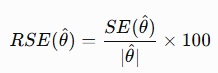

Não precisa estabelecer um limiar universal de bom ou ruim. O objetivo é mostrar que a estimativa direta vai ficando instável à medida que descemos de nível. E daí surgiria naturalmente a pergunta:

Se eu preciso de uma estimativa para o território, mas minha pesquisa não foi dimensionada para produzir uma estimativa direta precisa naquele território, o que faço?

Essa pergunta abre a aula de Small Area Estimation.

A amostragem complexa ensinou: use corretamente a informação que foi coletada.

Em nossao próxima aula, SAE acrescentará: quando a informação direta de uma pequena área é insuficiente, podemos combinar essa informação com outras fontes e modelos.
